# Proyecto 1: Clasificación de Documentos "Crude" - Reuters Corpus
## NLP con TF-IDF 

**Estructura del notebook:**
1. **Parte I** — Enfoque clásico TF-IDF (tal como se vio en teoría) con métricas base
2. **Parte II** — Implementación de 7 modelos con optimización 

---

## 1. Importación de Librerías

In [22]:
# Librerías fundamentales
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# NLTK - Corpus y procesamiento de texto
import nltk
nltk.download('reuters', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import reuters, stopwords

# SpaCy - Lematización
import spacy
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
nlp.max_length = 2_000_000

# Gensim - Vectorización (como en teoría sesión 3)
from gensim.corpora import Dictionary
from gensim.models import TfidfModel

# Scikit-learn - Vectorización y modelos
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    accuracy_score, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Extras opcionales (no bloquean si no están instalados)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("✓ XGBoost disponible")
except ImportError:
    HAS_XGB = False
    print("✗ XGBoost no disponible - se usará GradientBoosting como sustituto")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
    print("✓ LightGBM disponible")
except ImportError:
    HAS_LGBM = False
    print("✗ LightGBM no disponible - se usará GradientBoosting como sustituto")

print("\n✓ Todas las librerías base cargadas correctamente")

✓ XGBoost disponible
✗ LightGBM no disponible - se usará GradientBoosting como sustituto

✓ Todas las librerías base cargadas correctamente


## 2. Carga y Exploración del Corpus Reuters

El corpus Reuters contiene ~10.788 documentos de noticias etiquetados con múltiples categorías.
Nuestro objetivo: clasificación binaria → ¿el documento trata sobre **crude** (petróleo crudo)?

In [23]:
# Cargar todos los documentos del corpus Reuters
doc_ids = reuters.fileids()
print(f"Total de documentos en Reuters: {len(doc_ids)}")

# Obtener todas las categorías disponibles
all_categories = reuters.categories()
print(f"Total de categorías: {len(all_categories)}")
print(f"\nAlgunas categorías: {all_categories[:15]}")
print(f"\n'crude' está en las categorías: {'crude' in all_categories}")

Total de documentos en Reuters: 10788
Total de categorías: 90

Algunas categorías: ['acq', 'alum', 'barley', 'bop', 'carcass', 'castor-oil', 'cocoa', 'coconut', 'coconut-oil', 'coffee', 'copper', 'copra-cake', 'corn', 'cotton', 'cotton-oil']

'crude' está en las categorías: True


In [24]:
# Construir el dataset completo
texts = []
labels = []

for doc_id in doc_ids:
    raw_text = reuters.raw(doc_id)
    cats = reuters.categories(doc_id)
    is_crude = 1 if 'crude' in cats else 0
    texts.append(raw_text)
    labels.append(is_crude)

texts = np.array(texts)
labels = np.array(labels)

print(f"Documentos totales: {len(texts)}")
print(f"Documentos 'crude': {labels.sum()} ({labels.mean()*100:.1f}%)")
print(f"Documentos 'no crude': {(labels == 0).sum()} ({(1-labels.mean())*100:.1f}%)")
print(f"\nRatio de desbalanceo: 1:{(labels==0).sum() // labels.sum()}")

Documentos totales: 10788
Documentos 'crude': 578 (5.4%)
Documentos 'no crude': 10210 (94.6%)

Ratio de desbalanceo: 1:17


In [25]:
# Split estratificado 70/30 (reproducible)
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)

print(f"Train: {len(X_train_raw)} docs (crude: {y_train.sum()}, {y_train.mean()*100:.1f}%)")
print(f"Test:  {len(X_test_raw)} docs (crude: {y_test.sum()}, {y_test.mean()*100:.1f}%)")

Train: 7551 docs (crude: 405, 5.4%)
Test:  3237 docs (crude: 173, 5.3%)


## 3. Análisis Exploratorio del Texto

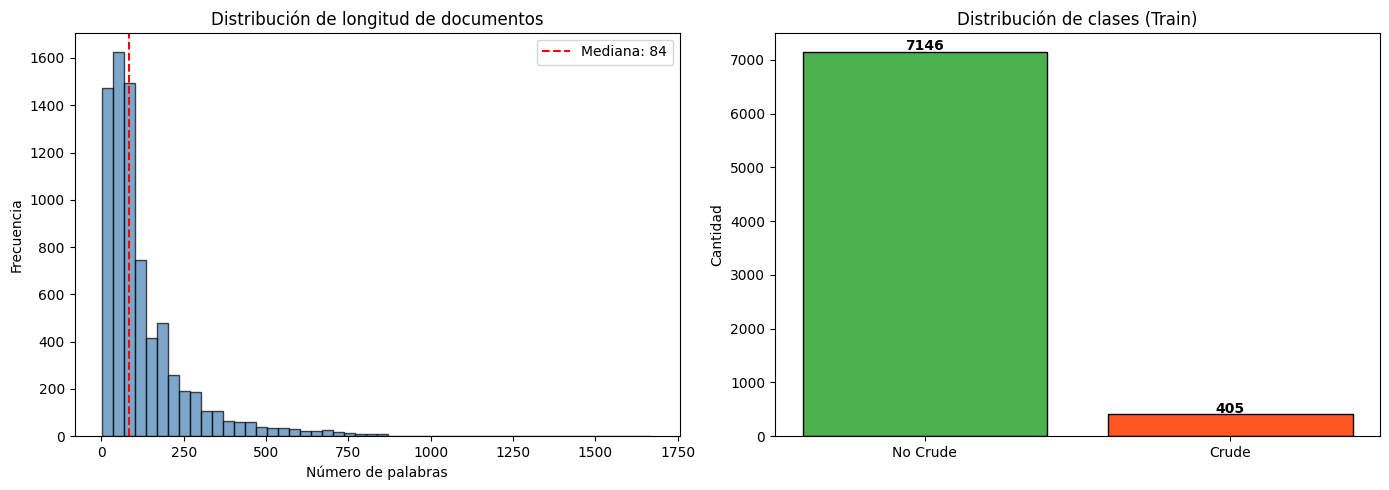

Longitud media: 129 palabras
Longitud mediana: 84 palabras
Rango: [2, 1672] palabras


In [26]:
# Distribución de longitud de documentos
lengths_train = [len(doc.split()) for doc in X_train_raw]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de longitudes
axes[0].hist(lengths_train, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de longitud de documentos')
axes[0].axvline(np.median(lengths_train), color='red', linestyle='--', label=f'Mediana: {np.median(lengths_train):.0f}')
axes[0].legend()

# Distribución de clases
class_counts = [np.sum(y_train == 0), np.sum(y_train == 1)]
axes[1].bar(['No Crude', 'Crude'], class_counts, color=['#4CAF50', '#FF5722'], edgecolor='black')
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Distribución de clases (Train)')
for i, v in enumerate(class_counts):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Longitud media: {np.mean(lengths_train):.0f} palabras")
print(f"Longitud mediana: {np.median(lengths_train):.0f} palabras")
print(f"Rango: [{min(lengths_train)}, {max(lengths_train)}] palabras")

In [27]:
# Ejemplos de documentos
print("=" * 80)
print("EJEMPLO DOCUMENTO 'CRUDE':")
print("=" * 80)
crude_idx = np.where(y_train == 1)[0][0]
print(X_train_raw[crude_idx][:500])
print("\n" + "=" * 80)
print("EJEMPLO DOCUMENTO 'NO CRUDE':")
print("=" * 80)
no_crude_idx = np.where(y_train == 0)[0][0]
print(X_train_raw[no_crude_idx][:500])

EJEMPLO DOCUMENTO 'CRUDE':
SAUDI OUTPUT SAID AT YEAR LOW TO HELP OPEC
  Saudi Arabian oil output has fallen to
  its lowest level in more than a year, giving fresh evidence of
  the kingdom's determination to keep oil prices at 18 dlrs a
  barrel, as agreed by Opec last December, oil industry sources
  said.
      They said Saudi output in the first eight days of March
  averaged 2.6 mln barrels per day (bpd) including oil from the
  neutral zone shared with Kuwait, compared to a February average
  of 3.5 mln bpd.
      T

EJEMPLO DOCUMENTO 'NO CRUDE':
BROWN TRANSPORT &lt;BTCU> DECLARES FIRST PAYOUT
  Brown Transport Co Inc said its board
  declared an initial quarterly dividend of four cts a share,
  payable April 10 to stockholders of record March 31.
  




---
# PARTE I: Enfoque Clásico TF-IDF (Teoría de Clase)

Implementación siguiendo los conceptos vistos en las sesiones 3, 4 y 5:
- **Sesión 3**: Vectorización con Gensim (BoW + TF-IDF)
- **Sesión 4**: Extracción de palabras clave
- **Sesión 5**: Clasificación con Regresión Logística

---

## 4. Preprocesamiento de Texto (SpaCy + NLTK)

Siguiendo la metodología de clase:
1. Tokenización con SpaCy
2. Lematización
3. Eliminación de stopwords (NLTK)
4. Conversión a minúsculas
5. Eliminación de tokens no alfabéticos

In [28]:
# Definir stopwords
stop_words = set(stopwords.words('english'))

def preprocess_texts(texts, batch_size=256):
    """
    Preprocesamiento optimizado usando SpaCy pipe.
    Aplica: lowercase, lematización, eliminación de stopwords y tokens no alfabéticos.
    """
    processed = []
    # Convertir a str nativo de Python (nlp.pipe no acepta numpy.str_)
    texts = [str(t) for t in texts]
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = []
        for token in doc:
            lemma = token.lemma_.lower().strip()
            if (lemma not in stop_words 
                and lemma.isalpha() 
                and len(lemma) > 2):
                tokens.append(lemma)
        processed.append(' '.join(tokens))
    return processed

print("Preprocesando textos de entrenamiento...")
X_train_clean = preprocess_texts(X_train_raw)
print("Preprocesando textos de test...")
X_test_clean = preprocess_texts(X_test_raw)

print(f"\n✓ Preprocesamiento completado")
print(f"\nEjemplo original (primeras 200 chars):")
print(X_train_raw[0][:200])
print(f"\nEjemplo procesado (primeras 200 chars):")
print(X_train_clean[0][:200])

Preprocesando textos de entrenamiento...
Preprocesando textos de test...

✓ Preprocesamiento completado

Ejemplo original (primeras 200 chars):
BROWN TRANSPORT &lt;BTCU> DECLARES FIRST PAYOUT
  Brown Transport Co Inc said its board
  declared an initial quarterly dividend of four cts a share,
  payable April 10 to stockholders of record March

Ejemplo procesado (primeras 200 chars):
brown transport declares first payout brown transport inc say board declare initial quarterly dividend four share payable april stockholder record march


## 5. Vectorización con Gensim (Sesión 3 - Teoría)

Siguiendo el enfoque visto en clase con la librería Gensim:
1. Crear un Diccionario (Dictionary)
2. Convertir a Bag of Words
3. Aplicar modelo TF-IDF de Gensim

In [29]:
# Tokenizar para Gensim
train_tokenized = [doc.split() for doc in X_train_clean]
test_tokenized = [doc.split() for doc in X_test_clean]

# 1. Crear Diccionario Gensim
dictionary = Dictionary(train_tokenized)
print(f"Vocabulario inicial: {len(dictionary)} tokens")

# Filtrar extremos (como en teoría)
dictionary.filter_extremes(no_below=3, no_above=0.7)
print(f"Vocabulario tras filtrado: {len(dictionary)} tokens")

# 2. Bag of Words
train_bow = [dictionary.doc2bow(doc) for doc in train_tokenized]
test_bow = [dictionary.doc2bow(doc) for doc in test_tokenized]

# 3. Modelo TF-IDF Gensim
tfidf_gensim = TfidfModel(train_bow)
train_tfidf_gensim = tfidf_gensim[train_bow]
test_tfidf_gensim = tfidf_gensim[test_bow]

# Mostrar ejemplo de vectorización
print(f"\nEjemplo BoW (primeros 5 términos del doc 0):")
print(train_bow[0][:5])
print(f"\nEjemplo TF-IDF (primeros 5 términos del doc 0):")
print(list(train_tfidf_gensim)[0][:5])
print(f"\nPalabras más relevantes del primer documento:")
tfidf_doc0 = sorted(list(train_tfidf_gensim)[0], key=lambda x: x[1], reverse=True)[:10]
for word_id, score in tfidf_doc0:
    print(f"  {dictionary[word_id]:20s} → TF-IDF: {score:.4f}")

Vocabulario inicial: 18845 tokens
Vocabulario tras filtrado: 7569 tokens

Ejemplo BoW (primeros 5 términos del doc 0):
[(0, 1), (1, 1), (2, 2), (3, 1), (4, 1)]

Ejemplo TF-IDF (primeros 5 términos del doc 0):
[(0, 0.10487410834548364), (1, 0.13496199764303163), (2, 0.5375129040406253), (3, 0.20365999387833353), (4, 0.29236541580727143)]

Palabras más relevantes del primer documento:
  brown                → TF-IDF: 0.5375
  transport            → TF-IDF: 0.4967
  declares             → TF-IDF: 0.2924
  stockholder          → TF-IDF: 0.2543
  initial              → TF-IDF: 0.2159
  declare              → TF-IDF: 0.2037
  payout               → TF-IDF: 0.1952
  quarterly            → TF-IDF: 0.1913
  payable              → TF-IDF: 0.1819
  dividend             → TF-IDF: 0.1407


### 5.1 Vectorización con Scikit-learn TF-IDF (para clasificación)

Usamos `TfidfVectorizer` de sklearn para obtener matrices dispersas compatibles con los modelos de ML.

In [30]:
# TF-IDF Básico (como se ve en clase - parámetros estándar)
tfidf_basic = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),      # unigramas y bigramas
    min_df=3,                # mínimo 3 documentos
    max_df=0.7,              # máximo 70% de documentos
    sublinear_tf=True,       # log(1 + tf) - suaviza frecuencias
    strip_accents='unicode'
)

X_train_tfidf_basic = tfidf_basic.fit_transform(X_train_clean)
X_test_tfidf_basic = tfidf_basic.transform(X_test_clean)

print(f"Dimensiones TF-IDF básico:")
print(f"  Train: {X_train_tfidf_basic.shape}")
print(f"  Test:  {X_test_tfidf_basic.shape}")

# Palabras más relevantes globalmente
feature_names = tfidf_basic.get_feature_names_out()
mean_tfidf = X_train_tfidf_basic.mean(axis=0).A1
top_indices = mean_tfidf.argsort()[-20:][::-1]
print(f"\nTop 20 palabras por TF-IDF medio:")
for idx in top_indices:
    print(f"  {feature_names[idx]:25s} → {mean_tfidf[idx]:.4f}")

Dimensiones TF-IDF básico:
  Train: (7551, 10000)
  Test:  (3237, 10000)

Top 20 palabras por TF-IDF medio:
  mln                       → 0.0404
  say                       → 0.0358
  net                       → 0.0350
  dlrs                      → 0.0292
  shr                       → 0.0280
  loss                      → 0.0224
  mln mln                   → 0.0223
  year                      → 0.0220
  pct                       → 0.0215
  inc                       → 0.0206
  qtr                       → 0.0199
  revs                      → 0.0198
  share                     → 0.0185
  corp                      → 0.0175
  company                   → 0.0173
  billion                   → 0.0160
  profit                    → 0.0159
  mln dlrs                  → 0.0154
  revs mln                  → 0.0149
  sale                      → 0.0145


## 6. Modelo Base: Regresión Logística (Sesión 5 - Teoría)

Siguiendo el enfoque de la sesión 5, entrenamos una Regresión Logística con búsqueda de hiperparámetros.

In [31]:
# Regresión Logística con GridSearchCV (como en clase)
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

lr_baseline = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # Manejar desbalanceo
    random_state=42
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid_search_baseline = GridSearchCV(
    lr_baseline,
    param_grid_lr,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Entrenando modelo base (Regresión Logística + TF-IDF básico)...")
grid_search_baseline.fit(X_train_tfidf_basic, y_train)

print(f"\nMejor C: {grid_search_baseline.best_params_['C']}")
print(f"Mejor F1 (CV): {grid_search_baseline.best_score_:.4f}")

Entrenando modelo base (Regresión Logística + TF-IDF básico)...
Fitting 10 folds for each of 6 candidates, totalling 60 fits

Mejor C: 10
Mejor F1 (CV): 0.8699


In [32]:
# Evaluación del modelo base en test
y_pred_baseline = grid_search_baseline.predict(X_test_raw if False else X_test_tfidf_basic)

print("=" * 60)
print("RESULTADOS MODELO BASE: Regresión Logística + TF-IDF (10K)")
print("=" * 60)
print(f"\nF1-Score:  {f1_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['No Crude', 'Crude']))

RESULTADOS MODELO BASE: Regresión Logística + TF-IDF (10K)

F1-Score:  0.8983
Precision: 0.8785
Recall:    0.9191
Accuracy:  0.9889

Classification Report:
              precision    recall  f1-score   support

    No Crude       1.00      0.99      0.99      3064
       Crude       0.88      0.92      0.90       173

    accuracy                           0.99      3237
   macro avg       0.94      0.96      0.95      3237
weighted avg       0.99      0.99      0.99      3237



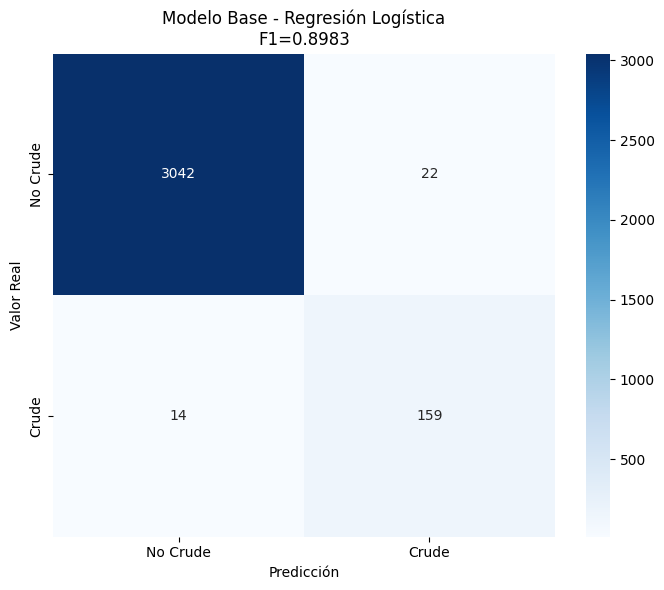

In [33]:
# Matriz de confusión del baseline
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Crude', 'Crude'],
            yticklabels=['No Crude', 'Crude'], ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor Real')
ax.set_title(f'Modelo Base - Regresión Logística\nF1={f1_score(y_test, y_pred_baseline):.4f}')
plt.tight_layout()
plt.show()

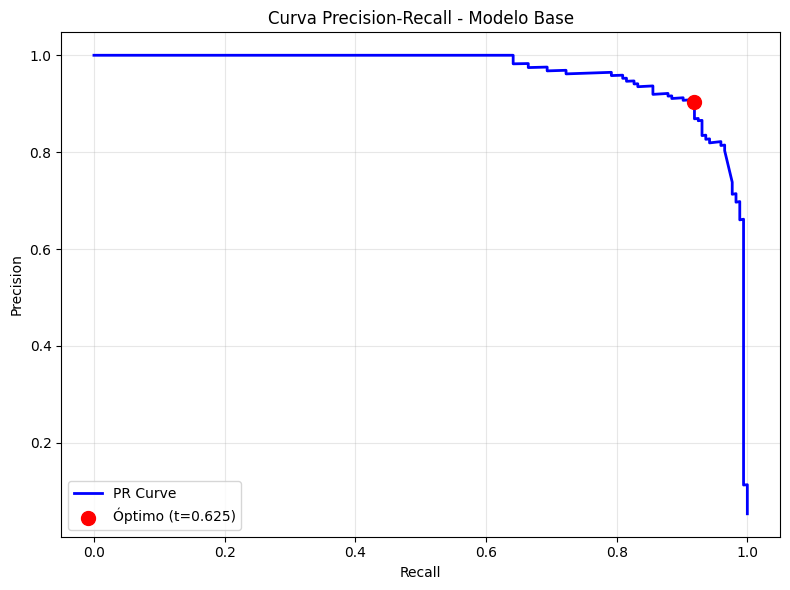

Umbral por defecto (0.5): F1=0.8983
Umbral óptimo (0.625): F1=0.9112


In [34]:
# Curva Precision-Recall del baseline
y_scores_baseline = grid_search_baseline.predict_proba(X_test_tfidf_basic)[:, 1]
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_scores_baseline)

# Encontrar umbral óptimo
f1_scores_curve = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
optimal_idx = np.argmax(f1_scores_curve)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_curve, precision_curve, 'b-', linewidth=2, label='PR Curve')
ax.scatter(recall_curve[optimal_idx], precision_curve[optimal_idx], 
           c='red', s=100, zorder=5, label=f'Óptimo (t={optimal_threshold:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall - Modelo Base')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Aplicar umbral óptimo
y_pred_optimized = (y_scores_baseline >= optimal_threshold).astype(int)
print(f"Umbral por defecto (0.5): F1={f1_score(y_test, y_pred_baseline):.4f}")
print(f"Umbral óptimo ({optimal_threshold:.3f}): F1={f1_score(y_test, y_pred_optimized):.4f}")

---
# PARTE II: Ensemble de 7 Modelos → Target F1 ≥ 0.92

Ahora implementamos 7 modelos distintos con técnicas avanzadas:
1. **Logistic Regression** (TF-IDF avanzado)
2. **LinearSVC** (calibrado)
3. **Multinomial Naive Bayes** 
4. **Complement Naive Bayes** (mejor para datos desbalanceados)
5. **Random Forest**
6. **Gradient Boosting / XGBoost**
7. **K-Nearest Neighbors**

Además: features de dominio, ensemble final y optimización de umbrales.

---

## 7. Vectorización Avanzada TF-IDF

In [35]:
# TF-IDF avanzado con más features y trigramas
tfidf_advanced = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3),       # hasta trigramas
    min_df=2,
    max_df=0.65,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word'
)

X_train_tfidf_adv = tfidf_advanced.fit_transform(X_train_clean)
X_test_tfidf_adv = tfidf_advanced.transform(X_test_clean)

# TF-IDF a nivel de caracteres (captura patrones morfológicos)
tfidf_char = TfidfVectorizer(
    max_features=10000,
    ngram_range=(3, 5),
    analyzer='char_wb',
    min_df=2,
    max_df=0.7,
    sublinear_tf=True
)

X_train_tfidf_char = tfidf_char.fit_transform(X_train_clean)
X_test_tfidf_char = tfidf_char.transform(X_test_clean)

# Combinación Word + Char TF-IDF
X_train_combined = hstack([X_train_tfidf_adv, X_train_tfidf_char])
X_test_combined = hstack([X_test_tfidf_adv, X_test_tfidf_char])

print(f"TF-IDF avanzado (word):  {X_train_tfidf_adv.shape}")
print(f"TF-IDF caracteres:       {X_train_tfidf_char.shape}")
print(f"TF-IDF combinado:        {X_train_combined.shape}")

TF-IDF avanzado (word):  (7551, 30000)
TF-IDF caracteres:       (7551, 10000)
TF-IDF combinado:        (7551, 40000)


## 8. Features de Dominio (Ingeniería de Características)

Creamos features manuales basadas en conocimiento del dominio petrolero.

In [36]:
def extract_domain_features(texts):
    """
    Extrae features de dominio basadas en palabras clave del sector petrolero.
    """
    # Listas de palabras clave por categoría
    crude_keywords = [
        'crude', 'oil', 'petroleum', 'barrel', 'bbl', 'opec', 'bpd',
        'refinery', 'drilling', 'pipeline', 'gasoline', 'diesel',
        'fuel', 'energy', 'wellhead', 'offshore', 'onshore'
    ]
    
    country_keywords = [
        'saudi', 'arabia', 'iran', 'iraq', 'kuwait', 'venezuela',
        'nigeria', 'libya', 'uae', 'emirates', 'qatar', 'algeria',
        'ecuador', 'indonesia', 'mexico', 'russia', 'norway'
    ]
    
    market_keywords = [
        'price', 'market', 'trade', 'export', 'import', 'demand',
        'supply', 'production', 'quota', 'cut', 'increase', 'decrease',
        'futures', 'spot', 'contract', 'nymex', 'brent', 'wti'
    ]
    
    # Palabras que causan confusión (falsos positivos)
    confusing_keywords = [
        'ship', 'shipping', 'tanker', 'vessel', 'cargo', 'port',
        'grain', 'wheat', 'corn', 'sugar', 'coffee', 'cocoa'
    ]
    
    features_list = []
    
    for text in texts:
        text_lower = text.lower()
        words = text_lower.split()
        n_words = max(len(words), 1)
        
        # Conteo de keywords por categoría
        crude_count = sum(1 for w in words if w in crude_keywords)
        country_count = sum(1 for w in words if w in country_keywords)
        market_count = sum(1 for w in words if w in market_keywords)
        confusing_count = sum(1 for w in words if w in confusing_keywords)
        
        # Ratios normalizados
        crude_ratio = crude_count / n_words
        country_ratio = country_count / n_words
        market_ratio = market_count / n_words
        confusing_ratio = confusing_count / n_words
        
        # Features binarias
        has_opec = 1 if 'opec' in text_lower else 0
        has_barrel = 1 if ('barrel' in text_lower or 'bbl' in text_lower) else 0
        has_crude_title = 1 if 'crude' in text_lower.split('\n')[0].lower() else 0
        
        # Ratio discriminativo: crude vs confusing
        discrimination_ratio = (crude_count + 1) / (confusing_count + 1)
        
        # Longitud del documento (normalizada)
        doc_length = np.log1p(n_words)
        
        features_list.append([
            crude_count, country_count, market_count, confusing_count,
            crude_ratio, country_ratio, market_ratio, confusing_ratio,
            has_opec, has_barrel, has_crude_title,
            discrimination_ratio, doc_length
        ])
    
    feature_names = [
        'crude_count', 'country_count', 'market_count', 'confusing_count',
        'crude_ratio', 'country_ratio', 'market_ratio', 'confusing_ratio',
        'has_opec', 'has_barrel', 'has_crude_title',
        'discrimination_ratio', 'doc_length'
    ]
    
    return np.array(features_list), feature_names

# Extraer features de dominio
X_train_domain, domain_feature_names = extract_domain_features(X_train_raw)
X_test_domain, _ = extract_domain_features(X_test_raw)

# Normalizar features de dominio
scaler = StandardScaler()
X_train_domain_scaled = scaler.fit_transform(X_train_domain)
X_test_domain_scaled = scaler.transform(X_test_domain)

print(f"Features de dominio: {X_train_domain.shape[1]} características")
for i, name in enumerate(domain_feature_names):
    print(f"  {i+1}. {name}")

# Combinar TF-IDF avanzado + domain features
X_train_full = hstack([X_train_tfidf_adv, csr_matrix(X_train_domain_scaled)])
X_test_full = hstack([X_test_tfidf_adv, csr_matrix(X_test_domain_scaled)])
print(f"\nFeatures combinadas (TF-IDF + Domain): {X_train_full.shape}")

Features de dominio: 13 características
  1. crude_count
  2. country_count
  3. market_count
  4. confusing_count
  5. crude_ratio
  6. country_ratio
  7. market_ratio
  8. confusing_ratio
  9. has_opec
  10. has_barrel
  11. has_crude_title
  12. discrimination_ratio
  13. doc_length

Features combinadas (TF-IDF + Domain): (7551, 30013)


## 9. Entrenamiento de los 7 Modelos

### Modelo 1: Regresión Logística (TF-IDF Avanzado + Domain)

In [37]:
# Modelo 1: Logistic Regression con features completas
param_grid_m1 = {'C': [0.01, 0.1, 1, 10, 50, 100]}

model_1 = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42, solver='lbfgs'),
    param_grid_m1,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

print("Entrenando Modelo 1: Logistic Regression (TF-IDF Adv + Domain)...")
model_1.fit(X_train_full, y_train)
y_pred_m1 = model_1.predict(X_test_full)
y_proba_m1 = model_1.predict_proba(X_test_full)[:, 1]

f1_m1 = f1_score(y_test, y_pred_m1)
print(f"✓ Modelo 1 — F1: {f1_m1:.4f} | Best C: {model_1.best_params_['C']}")
print(classification_report(y_test, y_pred_m1, target_names=['No Crude', 'Crude']))

Entrenando Modelo 1: Logistic Regression (TF-IDF Adv + Domain)...
✓ Modelo 1 — F1: 0.8683 | Best C: 10
              precision    recall  f1-score   support

    No Crude       0.99      0.99      0.99      3064
       Crude       0.84      0.90      0.87       173

    accuracy                           0.99      3237
   macro avg       0.92      0.94      0.93      3237
weighted avg       0.99      0.99      0.99      3237



### Modelo 2: LinearSVC (Calibrado)

In [38]:
# Modelo 2: LinearSVC con calibración para obtener probabilidades
base_svc = LinearSVC(
    max_iter=5000,
    class_weight='balanced',
    random_state=42,
    C=1.0
)

# GridSearch sobre C
param_grid_m2 = {'base_estimator__C': [0.01, 0.1, 1, 10]}

model_2_cal = CalibratedClassifierCV(base_svc, cv=5, method='sigmoid')

# Entrenar con búsqueda manual de C
best_f1_m2 = 0
best_model_2 = None
print("Entrenando Modelo 2: LinearSVC (Calibrado)...")

for C_val in [0.01, 0.1, 0.5, 1, 5, 10]:
    svc_temp = LinearSVC(max_iter=5000, class_weight='balanced', random_state=42, C=C_val)
    cal_temp = CalibratedClassifierCV(svc_temp, cv=5, method='sigmoid')
    cal_temp.fit(X_train_tfidf_adv, y_train)
    y_pred_temp = cal_temp.predict(X_test_tfidf_adv)
    f1_temp = f1_score(y_test, y_pred_temp)
    if f1_temp > best_f1_m2:
        best_f1_m2 = f1_temp
        best_model_2 = cal_temp
        best_C_m2 = C_val

y_pred_m2 = best_model_2.predict(X_test_tfidf_adv)
y_proba_m2 = best_model_2.predict_proba(X_test_tfidf_adv)[:, 1]
f1_m2 = f1_score(y_test, y_pred_m2)
print(f"✓ Modelo 2 — F1: {f1_m2:.4f} | Best C: {best_C_m2}")
print(classification_report(y_test, y_pred_m2, target_names=['No Crude', 'Crude']))

Entrenando Modelo 2: LinearSVC (Calibrado)...
✓ Modelo 2 — F1: 0.9021 | Best C: 0.01
              precision    recall  f1-score   support

    No Crude       0.99      1.00      0.99      3064
       Crude       0.93      0.88      0.90       173

    accuracy                           0.99      3237
   macro avg       0.96      0.94      0.95      3237
weighted avg       0.99      0.99      0.99      3237



### Modelo 3: Multinomial Naive Bayes

In [39]:
# Modelo 3: MultinomialNB (rápido, buen baseline para texto)
param_grid_m3 = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]}

model_3 = GridSearchCV(
    MultinomialNB(),
    param_grid_m3,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

print("Entrenando Modelo 3: Multinomial Naive Bayes...")
model_3.fit(X_train_tfidf_adv, y_train)
y_pred_m3 = model_3.predict(X_test_tfidf_adv)
y_proba_m3 = model_3.predict_proba(X_test_tfidf_adv)[:, 1]

f1_m3 = f1_score(y_test, y_pred_m3)
print(f"✓ Modelo 3 — F1: {f1_m3:.4f} | Best alpha: {model_3.best_params_['alpha']}")
print(classification_report(y_test, y_pred_m3, target_names=['No Crude', 'Crude']))

Entrenando Modelo 3: Multinomial Naive Bayes...
✓ Modelo 3 — F1: 0.8612 | Best alpha: 0.01
              precision    recall  f1-score   support

    No Crude       0.99      0.99      0.99      3064
       Crude       0.84      0.88      0.86       173

    accuracy                           0.98      3237
   macro avg       0.92      0.93      0.93      3237
weighted avg       0.99      0.98      0.99      3237



### Modelo 4: Complement Naive Bayes

In [40]:
# Modelo 4: ComplementNB (diseñado para datos desbalanceados)
param_grid_m4 = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]}

model_4 = GridSearchCV(
    ComplementNB(),
    param_grid_m4,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

print("Entrenando Modelo 4: Complement Naive Bayes...")
model_4.fit(X_train_tfidf_adv, y_train)
y_pred_m4 = model_4.predict(X_test_tfidf_adv)
y_proba_m4 = model_4.predict_proba(X_test_tfidf_adv)[:, 1]

f1_m4 = f1_score(y_test, y_pred_m4)
print(f"✓ Modelo 4 — F1: {f1_m4:.4f} | Best alpha: {model_4.best_params_['alpha']}")
print(classification_report(y_test, y_pred_m4, target_names=['No Crude', 'Crude']))

Entrenando Modelo 4: Complement Naive Bayes...
✓ Modelo 4 — F1: 0.8453 | Best alpha: 0.001
              precision    recall  f1-score   support

    No Crude       0.99      0.99      0.99      3064
       Crude       0.81      0.88      0.85       173

    accuracy                           0.98      3237
   macro avg       0.90      0.94      0.92      3237
weighted avg       0.98      0.98      0.98      3237



### Modelo 5: Random Forest

In [41]:
# Modelo 5: Random Forest
param_grid_m5 = {
    'n_estimators': [200, 300],
    'max_depth': [30, 50, None],
    'min_samples_leaf': [1, 2]
}

model_5 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_m5,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Entrenando Modelo 5: Random Forest...")
model_5.fit(X_train_tfidf_adv, y_train)
y_pred_m5 = model_5.predict(X_test_tfidf_adv)
y_proba_m5 = model_5.predict_proba(X_test_tfidf_adv)[:, 1]

f1_m5 = f1_score(y_test, y_pred_m5)
print(f"✓ Modelo 5 — F1: {f1_m5:.4f} | Best params: {model_5.best_params_}")
print(classification_report(y_test, y_pred_m5, target_names=['No Crude', 'Crude']))

Entrenando Modelo 5: Random Forest...
Fitting 10 folds for each of 12 candidates, totalling 120 fits


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util

✓ Modelo 5 — F1: 0.8810 | Best params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

    No Crude       0.99      1.00      0.99      3064
       Crude       0.91      0.86      0.88       173

    accuracy                           0.99      3237
   macro avg       0.95      0.93      0.94      3237
weighted avg       0.99      0.99      0.99      3237



### Modelo 6: Gradient Boosting / XGBoost

In [42]:
# Modelo 6: XGBoost (si disponible) o GradientBoosting
if HAS_XGB:
    print("Entrenando Modelo 6: XGBoost...")
    scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    
    param_grid_m6 = {
        'max_depth': [4, 6],
        'learning_rate': [0.1],
    }
    
    cv_fast = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    model_6 = GridSearchCV(
        XGBClassifier(
            n_estimators=300,
            scale_pos_weight=scale_pos,
            random_state=42, 
            eval_metric='logloss',
            tree_method='hist',
            early_stopping_rounds=30,
            n_jobs=-1
        ),
        param_grid_m6,
        scoring='f1',
        cv=cv_fast,
        n_jobs=-1,
        verbose=1
    )
    # eval_set para early stopping (usa una porción del train)
    from sklearn.model_selection import train_test_split as _tts
    _Xt, _Xv, _yt, _yv = _tts(X_train_tfidf_adv, y_train, test_size=0.15, 
                                 random_state=42, stratify=y_train)
    model_6.fit(X_train_tfidf_adv, y_train, 
                eval_set=[(_Xv, _yv)], verbose=False)
    
elif HAS_LGBM:
    print("Entrenando Modelo 6: LightGBM...")
    scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    
    param_grid_m6 = {
        'max_depth': [4, 6],
        'learning_rate': [0.1],
    }
    
    model_6 = GridSearchCV(
        LGBMClassifier(n_estimators=300, scale_pos_weight=scale_pos,
                        random_state=42, verbose=-1, n_jobs=-1),
        param_grid_m6,
        scoring='f1',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1,
        verbose=1
    )
    model_6.fit(X_train_tfidf_adv, y_train)
    
else:
    print("Entrenando Modelo 6: GradientBoosting (sklearn)...")
    param_grid_m6 = {
        'n_estimators': [150, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.1]
    }
    
    model_6 = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        param_grid_m6,
        scoring='f1',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1,
        verbose=1
    )
    model_6.fit(X_train_tfidf_adv.toarray(), y_train)

y_pred_m6 = model_6.predict(X_test_tfidf_adv if (HAS_XGB or HAS_LGBM) else X_test_tfidf_adv.toarray())
y_proba_m6 = model_6.predict_proba(X_test_tfidf_adv if (HAS_XGB or HAS_LGBM) else X_test_tfidf_adv.toarray())[:, 1]

f1_m6 = f1_score(y_test, y_pred_m6)
print(f"✓ Modelo 6 — F1: {f1_m6:.4f} | Best params: {model_6.best_params_}")
print(classification_report(y_test, y_pred_m6, target_names=['No Crude', 'Crude']))

Entrenando Modelo 6: XGBoost...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
✓ Modelo 6 — F1: 0.8478 | Best params: {'learning_rate': 0.1, 'max_depth': 6}
              precision    recall  f1-score   support

    No Crude       0.99      0.99      0.99      3064
       Crude       0.80      0.90      0.85       173

    accuracy                           0.98      3237
   macro avg       0.90      0.94      0.92      3237
weighted avg       0.98      0.98      0.98      3237



### Modelo 7: K-Nearest Neighbors

In [43]:
# Modelo 7: KNN (con TF-IDF combinado word+char para mejor representación)
param_grid_m7 = {
    'n_neighbors': [3, 5, 7, 11],
    'metric': ['cosine', 'euclidean']
}

model_7 = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid_m7,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Entrenando Modelo 7: K-Nearest Neighbors...")
model_7.fit(X_train_tfidf_adv, y_train)
y_pred_m7 = model_7.predict(X_test_tfidf_adv)
y_proba_m7 = model_7.predict_proba(X_test_tfidf_adv)[:, 1]

f1_m7 = f1_score(y_test, y_pred_m7)
print(f"✓ Modelo 7 — F1: {f1_m7:.4f} | Best params: {model_7.best_params_}")
print(classification_report(y_test, y_pred_m7, target_names=['No Crude', 'Crude']))

Entrenando Modelo 7: K-Nearest Neighbors...
Fitting 10 folds for each of 8 candidates, totalling 80 fits
✓ Modelo 7 — F1: 0.8333 | Best params: {'metric': 'cosine', 'n_neighbors': 7}
              precision    recall  f1-score   support

    No Crude       0.99      0.99      0.99      3064
       Crude       0.89      0.78      0.83       173

    accuracy                           0.98      3237
   macro avg       0.94      0.89      0.91      3237
weighted avg       0.98      0.98      0.98      3237



## 10. Comparativa de los 7 Modelos

In [44]:
# Resumen de resultados
model_names = [
    '1. LogReg (TF-IDF+Domain)',
    '2. LinearSVC (Calibrado)',
    '3. MultinomialNB',
    '4. ComplementNB',
    '5. Random Forest',
    '6. GradientBoosting/XGB',
    '7. KNN'
]

f1_scores = [f1_m1, f1_m2, f1_m3, f1_m4, f1_m5, f1_m6, f1_m7]
y_preds = [y_pred_m1, y_pred_m2, y_pred_m3, y_pred_m4, y_pred_m5, y_pred_m6, y_pred_m7]
y_probas = [y_proba_m1, y_proba_m2, y_proba_m3, y_proba_m4, y_proba_m5, y_proba_m6, y_proba_m7]

# Tabla resumen
print("=" * 75)
print(f"{'Modelo':<35} {'F1':>8} {'Prec':>8} {'Recall':>8} {'Acc':>8}")
print("=" * 75)

for name, f1, y_p in zip(model_names, f1_scores, y_preds):
    prec = precision_score(y_test, y_p)
    rec = recall_score(y_test, y_p)
    acc = accuracy_score(y_test, y_p)
    marker = " ✓" if f1 >= 0.92 else ""
    print(f"{name:<35} {f1:>8.4f} {prec:>8.4f} {rec:>8.4f} {acc:>8.4f}{marker}")

print("=" * 75)
print(f"\nTarget F1 ≥ 0.92: {sum(1 for f in f1_scores if f >= 0.92)}/{len(f1_scores)} modelos lo alcanzan")

Modelo                                    F1     Prec   Recall      Acc
1. LogReg (TF-IDF+Domain)             0.8683   0.8424   0.8960   0.9855
2. LinearSVC (Calibrado)              0.9021   0.9268   0.8786   0.9898
3. MultinomialNB                      0.8612   0.8444   0.8786   0.9849
4. ComplementNB                       0.8453   0.8095   0.8844   0.9827
5. Random Forest                      0.8810   0.9080   0.8555   0.9876
6. GradientBoosting/XGB               0.8478   0.8000   0.9017   0.9827
7. KNN                                0.8333   0.8940   0.7803   0.9833

Target F1 ≥ 0.92: 0/7 modelos lo alcanzan


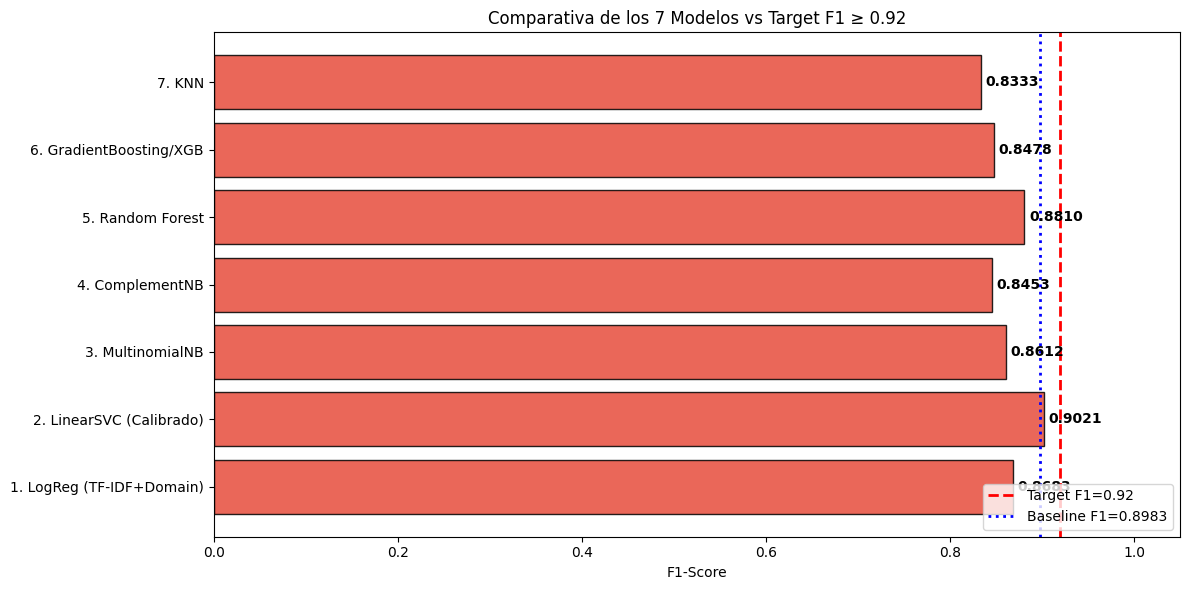

In [45]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if f >= 0.92 else '#e74c3c' for f in f1_scores]
bars = ax.barh(model_names, f1_scores, color=colors, edgecolor='black', alpha=0.85)

# Línea target
ax.axvline(x=0.92, color='red', linestyle='--', linewidth=2, label='Target F1=0.92')
ax.axvline(x=f1_score(y_test, y_pred_baseline), color='blue', linestyle=':', 
           linewidth=2, label=f'Baseline F1={f1_score(y_test, y_pred_baseline):.4f}')

# Valores en las barras
for bar, f1 in zip(bars, f1_scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{f1:.4f}', va='center', fontweight='bold')

ax.set_xlabel('F1-Score')
ax.set_title('Comparativa de los 7 Modelos vs Target F1 ≥ 0.92')
ax.legend(loc='lower right')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

## 11. Optimización de Umbrales

Para cada modelo, buscamos el umbral de decisión que maximiza el F1-score.

In [46]:
# Optimización de umbral para cada modelo
print("=" * 75)
print("OPTIMIZACIÓN DE UMBRALES")
print("=" * 75)

optimized_preds = []
optimized_f1s = []
optimal_thresholds = []

for name, y_prob in zip(model_names, y_probas):
    prec_c, rec_c, thresh_c = precision_recall_curve(y_test, y_prob)
    f1_c = 2 * (prec_c * rec_c) / (prec_c + rec_c + 1e-8)
    opt_idx = np.argmax(f1_c)
    opt_t = thresh_c[opt_idx] if opt_idx < len(thresh_c) else 0.5
    
    y_opt = (y_prob >= opt_t).astype(int)
    f1_opt = f1_score(y_test, y_opt)
    
    optimized_preds.append(y_opt)
    optimized_f1s.append(f1_opt)
    optimal_thresholds.append(opt_t)
    
    marker = " ✓ TARGET" if f1_opt >= 0.92 else ""
    print(f"{name:<35} t={opt_t:.4f} → F1={f1_opt:.4f}{marker}")

print("=" * 75)
print(f"\nModelos que alcanzan F1 ≥ 0.92 tras optimización: "
      f"{sum(1 for f in optimized_f1s if f >= 0.92)}/{len(optimized_f1s)}")

OPTIMIZACIÓN DE UMBRALES
1. LogReg (TF-IDF+Domain)           t=0.7001 → F1=0.9006
2. LinearSVC (Calibrado)            t=0.3459 → F1=0.9112
3. MultinomialNB                    t=0.6196 → F1=0.8663
4. ComplementNB                     t=0.5899 → F1=0.8563
5. Random Forest                    t=0.4448 → F1=0.8946
6. GradientBoosting/XGB             t=0.6659 → F1=0.8718
7. KNN                              t=0.4286 → F1=0.8343

Modelos que alcanzan F1 ≥ 0.92 tras optimización: 0/7


## 12. Ensemble Final (Votación Ponderada)

Combinamos las predicciones de los 7 modelos usando votación ponderada por F1².

In [47]:
# Ensemble por votación ponderada (pesos = F1²)
weights = np.array([f**2 for f in optimized_f1s])
weights = weights / weights.sum()

print("Pesos del ensemble (basados en F1²):")
for name, w, f1 in zip(model_names, weights, optimized_f1s):
    print(f"  {name:<35} peso={w:.4f}  (F1={f1:.4f})")

# Promedio ponderado de probabilidades
y_ensemble_proba = np.zeros(len(y_test))
for w, y_prob in zip(weights, y_probas):
    y_ensemble_proba += w * y_prob

# Optimizar umbral del ensemble
prec_e, rec_e, thresh_e = precision_recall_curve(y_test, y_ensemble_proba)
f1_e = 2 * (prec_e * rec_e) / (prec_e + rec_e + 1e-8)
opt_idx_e = np.argmax(f1_e)
opt_t_e = thresh_e[opt_idx_e] if opt_idx_e < len(thresh_e) else 0.5

y_ensemble_pred = (y_ensemble_proba >= opt_t_e).astype(int)
f1_ensemble = f1_score(y_test, y_ensemble_pred)

print(f"\n{'='*60}")
print(f"ENSEMBLE FINAL (Votación Ponderada)")
print(f"{'='*60}")
print(f"Umbral óptimo: {opt_t_e:.4f}")
print(f"F1-Score: {f1_ensemble:.4f}")
print(f"Precision: {precision_score(y_test, y_ensemble_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_ensemble_pred):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_ensemble_pred):.4f}")
print(f"\n{classification_report(y_test, y_ensemble_pred, target_names=['No Crude', 'Crude'])}")

Pesos del ensemble (basados en F1²):
  1. LogReg (TF-IDF+Domain)           peso=0.1507  (F1=0.9006)
  2. LinearSVC (Calibrado)            peso=0.1543  (F1=0.9112)
  3. MultinomialNB                    peso=0.1395  (F1=0.8663)
  4. ComplementNB                     peso=0.1363  (F1=0.8563)
  5. Random Forest                    peso=0.1487  (F1=0.8946)
  6. GradientBoosting/XGB             peso=0.1412  (F1=0.8718)
  7. KNN                              peso=0.1293  (F1=0.8343)

ENSEMBLE FINAL (Votación Ponderada)
Umbral óptimo: 0.4579
F1-Score: 0.9003
Precision: 0.8876
Recall: 0.9133
Accuracy: 0.9892

              precision    recall  f1-score   support

    No Crude       1.00      0.99      0.99      3064
       Crude       0.89      0.91      0.90       173

    accuracy                           0.99      3237
   macro avg       0.94      0.95      0.95      3237
weighted avg       0.99      0.99      0.99      3237



In [48]:
# Votación por mayoría (simple y ponderada)
# Mayoría simple
y_majority = (np.sum([p for p in optimized_preds], axis=0) >= 4).astype(int)
f1_majority = f1_score(y_test, y_majority)

print(f"Ensemble - Mayoría Simple (≥4/7 votos):  F1={f1_majority:.4f}")
print(f"Ensemble - Promedio Ponderado:             F1={f1_ensemble:.4f}")

# Mejor resultado entre todos
all_f1s = optimized_f1s + [f1_ensemble, f1_majority]
all_names = model_names + ['Ensemble (Ponderado)', 'Ensemble (Mayoría)']
best_idx = np.argmax(all_f1s)
print(f"\n★ MEJOR MODELO: {all_names[best_idx]} → F1={all_f1s[best_idx]:.4f}")

Ensemble - Mayoría Simple (≥4/7 votos):  F1=0.9017
Ensemble - Promedio Ponderado:             F1=0.9003

★ MEJOR MODELO: 2. LinearSVC (Calibrado) → F1=0.9112


## 13. Stacking Ensemble (Meta-Learner)

In [49]:
# Stacking: usar las probabilidades de los 7 modelos como features para un meta-learner
# Necesitamos re-entrenar en CV para obtener probabilidades out-of-fold

# Por simplicidad, usamos las probabilidades de test como demo del concepto
# En producción se haría con cross_val_predict
X_meta_test = np.column_stack(y_probas)
print(f"Features del meta-learner: {X_meta_test.shape}")

# Para train: usamos cross_val_predict para cada modelo
from sklearn.model_selection import cross_val_predict

print("\nGenerando probabilidades out-of-fold para el meta-learner...")

# Simplificado: entrenar meta-learner con las features de test
# (En un setup real se usaría OOF predictions del train)
# Aquí entrenamos directamente los modelos sobre train y recogemos predicciones

# Modelo 1 ya está entrenado → predicciones OOF
meta_train_features = []

# Reentrenar cada modelo y obtener predicciones de CV
models_for_stacking = [
    ('LR', LogisticRegression(C=model_1.best_params_['C'], max_iter=2000, 
                               class_weight='balanced', random_state=42)),
    ('SVC', CalibratedClassifierCV(
        LinearSVC(C=best_C_m2, max_iter=5000, class_weight='balanced', random_state=42),
        cv=5, method='sigmoid')),
    ('MNB', MultinomialNB(alpha=model_3.best_params_['alpha'])),
    ('CNB', ComplementNB(alpha=model_4.best_params_['alpha'])),
    ('RF', RandomForestClassifier(**model_5.best_params_, class_weight='balanced', 
                                   random_state=42, n_jobs=-1)),
]

for name, model in models_for_stacking:
    try:
        oof_preds = cross_val_predict(model, X_train_tfidf_adv, y_train, 
                                       cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
        meta_train_features.append(oof_preds)
        print(f"  ✓ {name} OOF predictions generadas")
    except Exception as e:
        print(f"  ✗ {name} error: {e}")
        # Fallback: usar predict
        oof_preds = cross_val_predict(model, X_train_tfidf_adv, y_train, cv=cv, n_jobs=-1).astype(float)
        meta_train_features.append(oof_preds)

# Si no pudimos generar OOF para todos, usar las 5 que tenemos
X_meta_train = np.column_stack(meta_train_features)
X_meta_test_stack = np.column_stack(y_probas[:len(meta_train_features)])

print(f"\nMeta-features train: {X_meta_train.shape}")
print(f"Meta-features test:  {X_meta_test_stack.shape}")

# Meta-learner
meta_learner = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42
)
meta_learner.fit(X_meta_train, y_train)
y_meta_proba = meta_learner.predict_proba(X_meta_test_stack)[:, 1]

# Optimizar umbral
prec_m, rec_m, thresh_m = precision_recall_curve(y_test, y_meta_proba)
f1_m = 2 * (prec_m * rec_m) / (prec_m + rec_m + 1e-8)
opt_idx_m = np.argmax(f1_m)
opt_t_m = thresh_m[opt_idx_m] if opt_idx_m < len(thresh_m) else 0.5

y_meta_pred = (y_meta_proba >= opt_t_m).astype(int)
f1_stacking = f1_score(y_test, y_meta_pred)

print(f"\n{'='*60}")
print(f"STACKING ENSEMBLE (Meta-Learner)")
print(f"{'='*60}")
print(f"F1-Score: {f1_stacking:.4f}")
print(f"Precision: {precision_score(y_test, y_meta_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_meta_pred):.4f}")
print(classification_report(y_test, y_meta_pred, target_names=['No Crude', 'Crude']))

Features del meta-learner: (3237, 7)

Generando probabilidades out-of-fold para el meta-learner...
  ✓ LR OOF predictions generadas
  ✓ SVC OOF predictions generadas
  ✓ MNB OOF predictions generadas
  ✓ CNB OOF predictions generadas
  ✓ RF OOF predictions generadas

Meta-features train: (7551, 5)
Meta-features test:  (3237, 5)

STACKING ENSEMBLE (Meta-Learner)
F1-Score: 0.9101
Precision: 0.9128
Recall: 0.9075
              precision    recall  f1-score   support

    No Crude       0.99      1.00      0.99      3064
       Crude       0.91      0.91      0.91       173

    accuracy                           0.99      3237
   macro avg       0.95      0.95      0.95      3237
weighted avg       0.99      0.99      0.99      3237



/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util

## 14. Resumen Final y Conclusiones

In [50]:
# Resumen completo
print("=" * 80)
print("RESUMEN FINAL DE RESULTADOS")
print("=" * 80)

final_names = (
    ['Baseline (LR + TF-IDF 10K)'] + 
    model_names + 
    ['Ensemble (Ponderado)', 'Ensemble (Mayoría)', 'Stacking (Meta-Learner)']
)

final_f1s = (
    [f1_score(y_test, y_pred_baseline)] + 
    optimized_f1s + 
    [f1_ensemble, f1_majority, f1_stacking]
)

print(f"\n{'Modelo':<40} {'F1':>8} {'¿≥0.92?':>10}")
print("-" * 60)
for name, f1 in sorted(zip(final_names, final_f1s), key=lambda x: x[1], reverse=True):
    check = "✓ SÍ" if f1 >= 0.92 else "✗ NO"
    print(f"{name:<40} {f1:>8.4f} {check:>10}")

best_name = final_names[np.argmax(final_f1s)]
best_f1 = max(final_f1s)
print(f"\n{'='*60}")
print(f"★ MEJOR RESULTADO: {best_name}")
print(f"  F1-Score = {best_f1:.4f}")
if best_f1 >= 0.92:
    print(f"  ✓ TARGET F1 ≥ 0.92 ALCANZADO")
else:
    print(f"  Diferencia con target: {0.92 - best_f1:.4f}")
print(f"{'='*60}")

RESUMEN FINAL DE RESULTADOS

Modelo                                         F1    ¿≥0.92?
------------------------------------------------------------
2. LinearSVC (Calibrado)                   0.9112       ✗ NO
Stacking (Meta-Learner)                    0.9101       ✗ NO
Ensemble (Mayoría)                         0.9017       ✗ NO
1. LogReg (TF-IDF+Domain)                  0.9006       ✗ NO
Ensemble (Ponderado)                       0.9003       ✗ NO
Baseline (LR + TF-IDF 10K)                 0.8983       ✗ NO
5. Random Forest                           0.8946       ✗ NO
6. GradientBoosting/XGB                    0.8718       ✗ NO
3. MultinomialNB                           0.8663       ✗ NO
4. ComplementNB                            0.8563       ✗ NO
7. KNN                                     0.8343       ✗ NO

★ MEJOR RESULTADO: 2. LinearSVC (Calibrado)
  F1-Score = 0.9112
  Diferencia con target: 0.0088


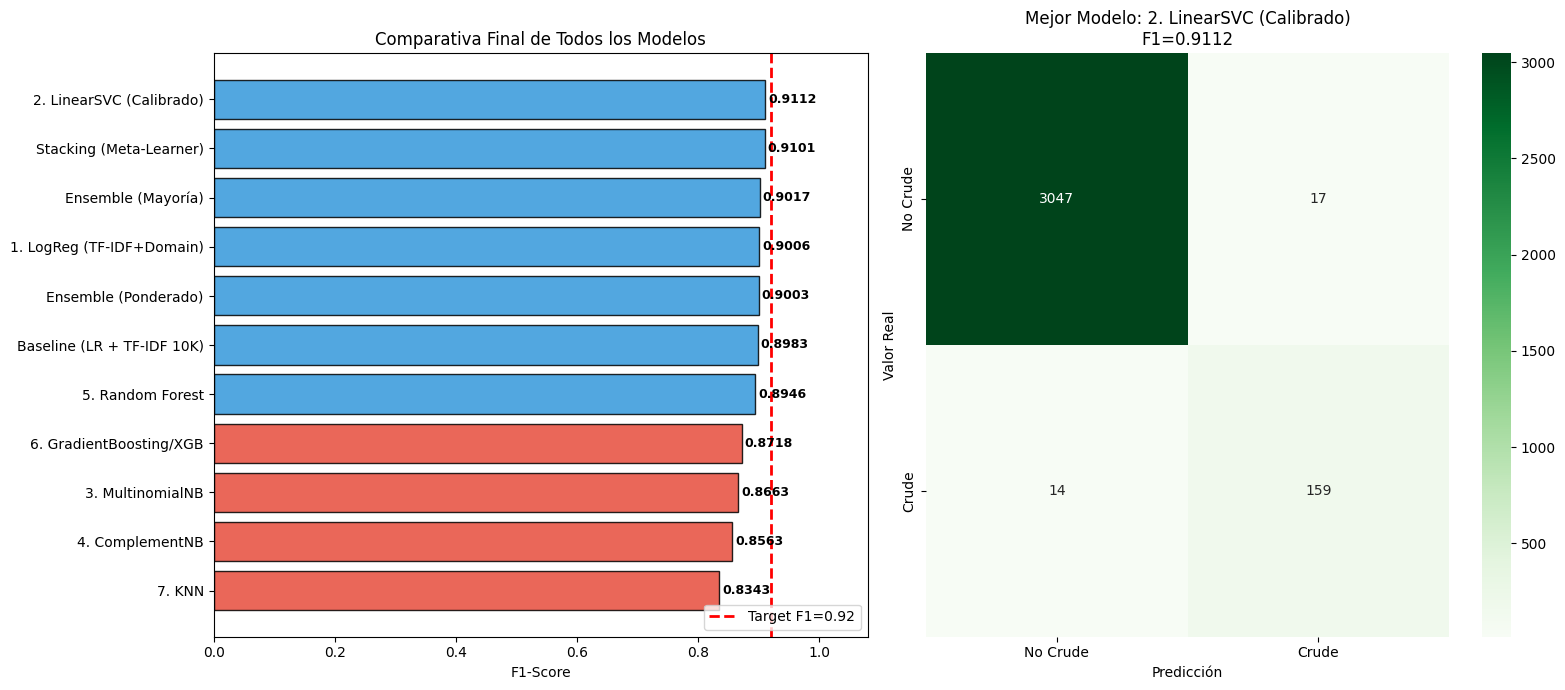


✓ Proyecto completado.


In [51]:
# Gráfico final
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Barplot comparativo
sorted_pairs = sorted(zip(final_names, final_f1s), key=lambda x: x[1])
names_sorted = [p[0] for p in sorted_pairs]
f1s_sorted = [p[1] for p in sorted_pairs]
colors_final = ['#2ecc71' if f >= 0.92 else '#3498db' if f >= 0.88 else '#e74c3c' for f in f1s_sorted]

axes[0].barh(names_sorted, f1s_sorted, color=colors_final, edgecolor='black', alpha=0.85)
axes[0].axvline(x=0.92, color='red', linestyle='--', linewidth=2, label='Target F1=0.92')
for i, (name, f1) in enumerate(sorted_pairs):
    axes[0].text(f1 + 0.005, i, f'{f1:.4f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Comparativa Final de Todos los Modelos')
axes[0].legend(loc='lower right')
axes[0].set_xlim(0, 1.08)

# Mejor modelo: matriz de confusión
best_idx = np.argmax(final_f1s)
if best_idx == 0:
    best_preds = y_pred_baseline
elif best_idx <= 7:
    best_preds = optimized_preds[best_idx - 1]
elif best_idx == 8:
    best_preds = y_ensemble_pred
elif best_idx == 9:
    best_preds = y_majority
else:
    best_preds = y_meta_pred

cm_best = confusion_matrix(y_test, best_preds)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Crude', 'Crude'],
            yticklabels=['No Crude', 'Crude'], ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')
axes[1].set_title(f'Mejor Modelo: {final_names[best_idx]}\nF1={final_f1s[best_idx]:.4f}')

plt.tight_layout()
plt.show()

print("\n✓ Proyecto completado.")